<link href="https://fonts.googleapis.com/css2?family=Cinzel:wght@600&display=swap" rel="stylesheet">

<h2 style="
text-align:center;
color:white;
font-family:'Cinzel', serif;
font-size:30px;
letter-spacing:3px;
text-shadow: 2px 2px 6px rgba(0,0,0,0.9);">
⚓ TITANIC SURVIVAL PREDICTION 🚢
</h2>

<p style="
text-align:center;
color:white;
font-size:14px;
font-family:'Cinzel', serif;
letter-spacing:1px;
text-shadow: 1px 1px 4px rgba(0,0,0,0.8);">
Machine Learning Classification Project
</p>

##### Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

##### Load Dataset


In [35]:
from IPython.display import display

df = pd.read_csv("titanic.csv")
display(df.head().style.set_caption("Titanic Dataset Preview"))

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.500000,0,0,330911,7.829200,nan,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.000000,1,0,363272,7.000000,nan,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.000000,0,0,240276,9.687500,nan,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.000000,0,0,315154,8.662500,nan,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.000000,1,1,3101298,12.287500,nan,S


##### Check missing values

In [31]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [23]:
info_df = pd.DataFrame({
    "Column": df.columns,
    "Non-Null Count": df.notnull().sum().values,
    "Data Type": df.dtypes.values
})

display(info_df)

,Column,Non-Null Count,Data Type
0,PassengerId,418,int64
1,Survived,418,int64
2,Pclass,418,int64
3,Name,418,object
4,Sex,418,object
5,Age,332,float64
6,SibSp,418,int64
7,Parch,418,int64
8,Ticket,418,object
9,Fare,417,float64


## EDA (Exploratory Data Analysis)


###### Survival Count


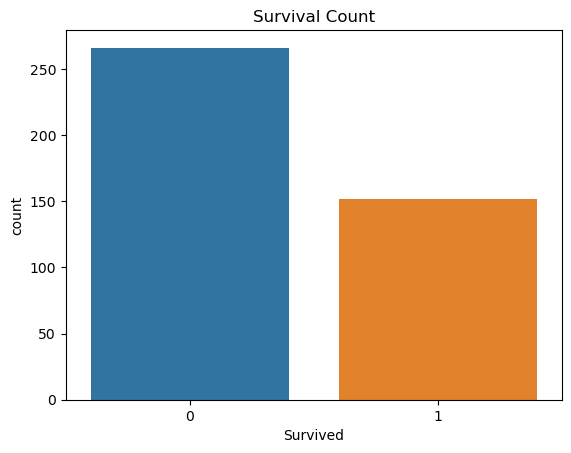

In [5]:
plt.figure()
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

#### Gender vs Survival

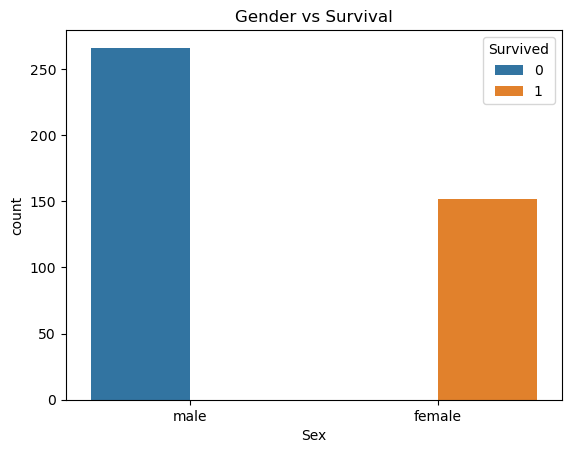

In [25]:
plt.figure()
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Gender vs Survival")
plt.show()

#### Passenger Class vs Survival


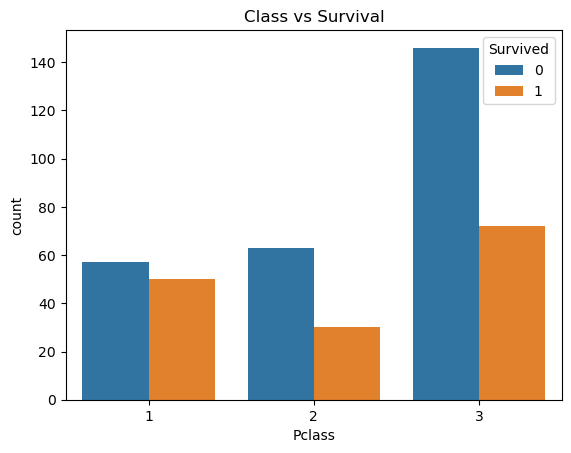

In [7]:
plt.figure()
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Class vs Survival")
plt.show()

#### Age Distribution


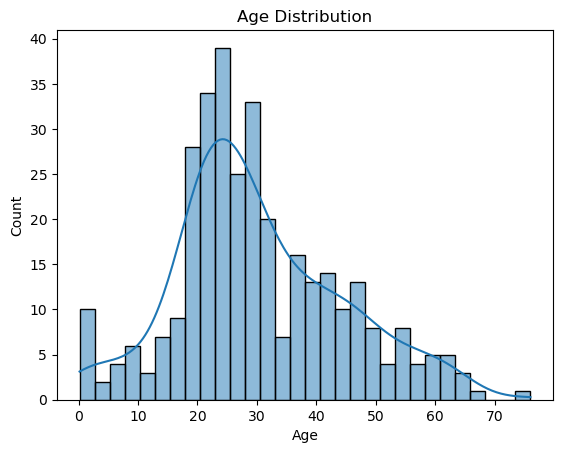

In [8]:
plt.figure()
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()


#### Fare Distribution


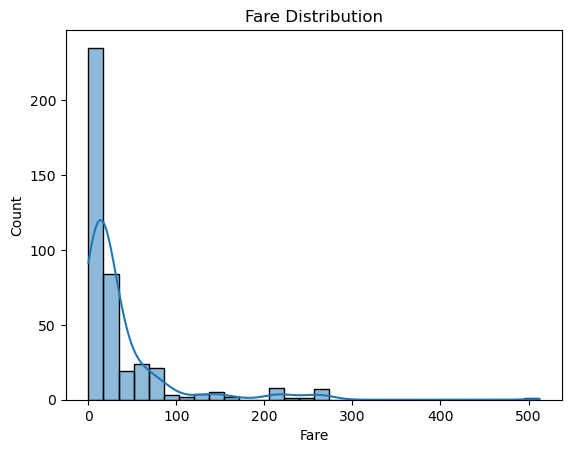

In [9]:
plt.figure()
sns.histplot(df['Fare'], bins=30, kde=True)
plt.title("Fare Distribution")
plt.show()


### Data Preprocessing


In [10]:
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])



###### Features & Target


In [11]:
X = df.drop('Survived', axis=1)
y = df['Survived']


###### Train Test Split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

###### Logistic Regression


In [12]:
log_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, solver='liblinear'))
])

log_pipeline.fit(X_train, y_train)
y_pred_log = log_pipeline.predict(X_test)

###### Random Forest


In [13]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

###### Model Accuracy Comparison 

In [ ]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

#### Evaluation Function


In [14]:
def evaluate(name, y_test, y_pred):
    print(f"\n{name}")
    print("="*30)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))


evaluate("Logistic Regression", y_test, y_pred_log)
evaluate("Random Forest", y_test, y_pred_rf)


Logistic Regression
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84


Random Forest
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



#### Confusion Matrix Plot


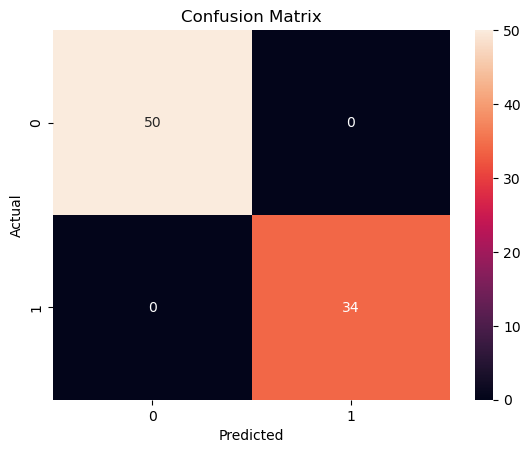

In [15]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


#### ROC Curve


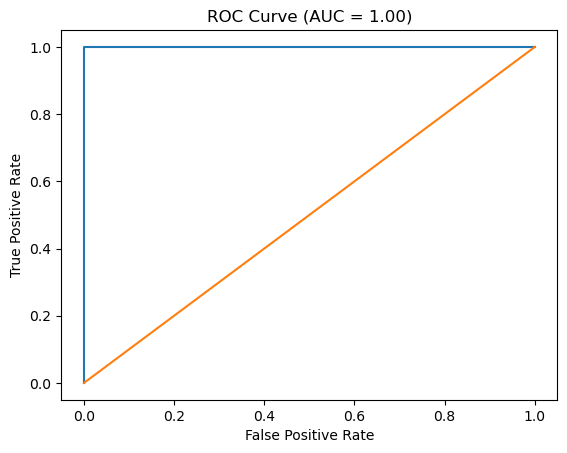

In [16]:
y_prob = rf_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.title(f"ROC Curve (AUC = {auc:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

#### Feature Importance


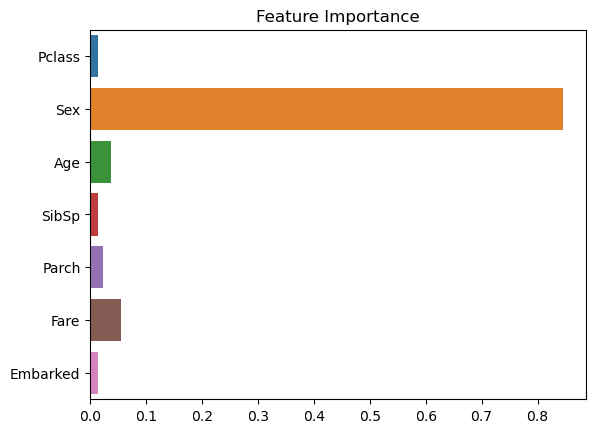

In [17]:
importance = rf_model.feature_importances_
features = X.columns

plt.figure()
sns.barplot(x=importance, y=features)
plt.title("Feature Importance")
plt.show()